# Tax Fraud Dataset — Data Inspection & Cleaning

**Goal:** load the raw dataset, understand its structure, find and fix missing
values and duplicates, check for outliers, apply a few extra sanity-check
cleanups, and export a cleaned version of the file that the next notebook
(`EDA.ipynb`) will build on.

Dataset: `tax_fraud_dataset.csv` (50,500 rows x 25 columns).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)
sns.set_style('whitegrid')

# Project structure: this notebook lives in notebooks/, data lives in data/
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR = PROJECT_ROOT / 'data'

## 1. Load Data

In [2]:
df = pd.read_csv(DATA_DIR / 'tax_fraud_dataset.csv')
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()


Shape: 50500 rows, 25 columns


,Taxpayer_ID,Business_Type,Region,Years_in_Business,Employee_Count,Annual_Revenue,Annual_Expenses,Net_Profit,Taxable_Income,Expected_Tax,Declared_Tax,VAT_Collected,VAT_Paid,Previous_Audits,Previous_Violations,Late_Payments,Industry_Risk,Cash_Transactions_Percentage,Missing_Documents,Invoice_Mismatch,Expense_Ratio,Profit_Margin,Revenue_per_Employee,Tax_Gap,Fraud
0,100000,Restaurant,Cairo,10,9,1892448.36,839511.26,1052937.10,919634.40,206917.74,200930.13,264942.77,117531.58,2,0,0,Medium,58.87,0,0,0.444,0.556,210272.04,5987.61,0
1,100001,Pharmacy,Giza,0,17,2129742.33,923661.40,1206080.92,1078021.30,242554.79,234562.43,298163.93,129312.60,1,0,1,Low,5.98,0,0,0.434,0.566,125278.96,7992.36,0
2,100002,Restaurant,Sharqia,4,8,789223.93,334017.67,455206.26,420736.46,94665.70,81056.42,110491.35,46762.47,1,0,0,Medium,69.98,4,1,0.423,0.577,98652.99,13609.28,1
3,100003,Manufacturing,Cairo,7,8,427211.55,361951.79,65259.77,58963.05,13266.69,12816.14,59809.62,50673.25,2,0,0,Medium,42.56,1,0,0.847,0.153,53401.44,450.54,0
4,100004,Import/Export,Sharqia,3,8,1516452.68,831833.16,684619.52,588453.59,132402.06,130966.03,212303.38,116456.64,0,1,2,High,39.09,1,0,0.549,0.451,189556.58,1436.03,0


## 2. Check Structure

Look at the data type Pandas assigned to each column (numeric vs text) and
some summary statistics, to make sure nothing looks obviously wrong before we
start cleaning.


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50500 entries, 0 to 50499
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Taxpayer_ID                   50500 non-null  int64  
 1   Business_Type                 48992 non-null  object 
 2   Region                        48992 non-null  object 
 3   Years_in_Business             50500 non-null  int64  
 4   Employee_Count                50500 non-null  int64  
 5   Annual_Revenue                50500 non-null  float64
 6   Annual_Expenses               50500 non-null  float64
 7   Net_Profit                    50500 non-null  float64
 8   Taxable_Income                50500 non-null  float64
 9   Expected_Tax                  50500 non-null  float64
 10  Declared_Tax                  50500 non-null  float64
 11  VAT_Collected                 50500 non-null  float64
 12  VAT_Paid                      50500 non-null  float64
 13  P

In [4]:
# Numeric columns summary
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Taxpayer_ID,50500.0,1.250004e+05,1.443702e+04,100000.00,112499.7500,125003.500,1.375022e+05,149999.00
Years_in_Business,50500.0,7.642792e+00,4.704259e+00,0.00,4.0000,7.000,1.100000e+01,27.00
Employee_Count,50500.0,1.143994e+01,7.790430e+00,1.00,6.0000,10.000,1.500000e+01,101.00
Annual_Revenue,50500.0,1.537850e+06,1.236956e+06,78160.24,747498.9450,1202441.525,1.926257e+06,24429290.97
Annual_Expenses,50500.0,1.000010e+06,8.764323e+05,38489.42,453623.7050,755297.215,1.250683e+06,20975507.04
Net_Profit,50500.0,5.378404e+05,5.509296e+05,5901.86,192019.6800,373035.045,6.917697e+05,10362920.24
Taxable_Income,50500.0,4.976913e+05,5.114754e+05,5168.70,176830.6825,344793.435,6.404727e+05,10221459.62
Expected_Tax,50500.0,1.119806e+05,1.150820e+05,1162.96,39786.9000,77578.520,1.441063e+05,2299828.41
Declared_Tax,50500.0,1.083924e+05,1.116677e+05,1142.52,38468.5325,74918.610,1.392679e+05,2236481.08
VAT_Collected,50500.0,2.152990e+05,1.731739e+05,10942.43,104649.8500,168341.815,2.696759e+05,3420100.74


In [5]:
# Categorical columns summary
df.describe(include='object').T


,count,unique,top,freq
Business_Type,48992,9,Construction,5542
Region,48992,8,Sharqia,6251
Industry_Risk,50500,3,Low,22382


## 3. Find Missing Values

Count how many cells (and rows) are empty per column, and figure out whether
it's better to fill or drop them.


In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_table = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_table = missing_table[missing_table['missing_count'] > 0].sort_values('missing_count', ascending=False)
missing_table


,missing_count,missing_pct
Business_Type,1508,2.99
Region,1508,2.99
Cash_Transactions_Percentage,1508,2.99


Rows with at least one missing value: 1508 (2.99% of all rows)


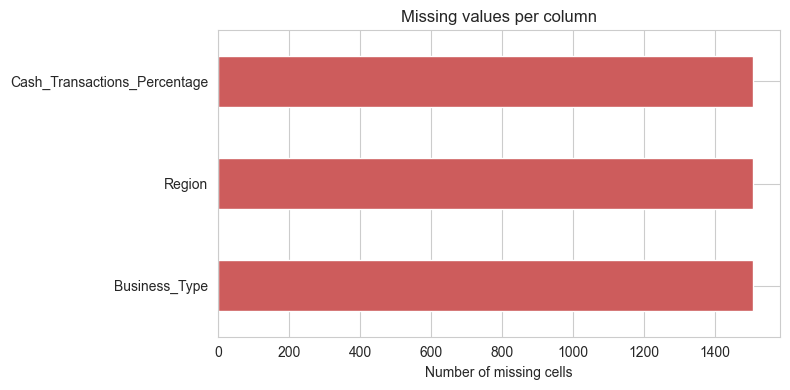

In [7]:
rows_with_missing = df.isnull().any(axis=1).sum()
print(f"Rows with at least one missing value: {rows_with_missing} ({rows_with_missing/len(df)*100:.2f}% of all rows)")

# visualize which columns have missing data
plt.figure(figsize=(8, 4))
missing_table['missing_count'].plot(kind='barh', color='indianred')
plt.xlabel('Number of missing cells')
plt.title('Missing values per column')
plt.tight_layout()
plt.show()


### Decision: fill or drop?

A few things worth checking before deciding: do the missing cells fall in the
same rows, and are those rows more or less likely to be fraud than the rest
(i.e. is the missingness related to our target)?


In [8]:
missing_cols = missing_table.index.tolist()
print("Columns with missing values:", missing_cols)

# do these columns go missing together, in the same rows?
miss_per_row = df[missing_cols].isnull().sum(axis=1)
print(miss_per_row.value_counts())

# is missingness related to fraud? if the fraud rate is similar with/without
# missing data, the missingness is unrelated to the target and safe to handle
# without introducing bias
rows_missing = df[df.isnull().any(axis=1)]
rows_complete = df[~df.isnull().any(axis=1)]
print(f"\nFraud rate in rows WITH missing values:    {rows_missing['Fraud'].mean():.3f}")
print(f"Fraud rate in rows WITHOUT missing values: {rows_complete['Fraud'].mean():.3f}")
print(f"\nFraud rows that would be LOST if we dropped these rows: {rows_missing['Fraud'].sum()} "
      f"({rows_missing['Fraud'].sum()/df['Fraud'].sum()*100:.2f}% of all fraud cases)")


Columns with missing values: ['Business_Type', 'Region', 'Cash_Transactions_Percentage']
0    48992
3     1508
Name: count, dtype: int64

Fraud rate in rows WITH missing values:    0.101
Fraud rate in rows WITHOUT missing values: 0.107

Fraud rows that would be LOST if we dropped these rows: 153 (2.82% of all fraud cases)


**Decision: fill, don't drop.**

- `Business_Type`, `Region`, and `Cash_Transactions_Percentage` are always
  missing together in the same ~1,500 rows (~3% of the data) — a single
  missing "batch", not scattered randomly across many columns.
- The fraud rate in those rows (~10.1%) is essentially the same as in the
  rest of the data (~10.7%), so the missingness isn't related to fraud —
  it's safe to fill without biasing the target.
- Dropping those rows would throw away roughly 150 confirmed fraud cases
  (~2.8% of all fraud examples we have) purely because 3 unrelated columns
  are blank. Fraud is already a rare class (~10.7%), so every fraud row is
  valuable — filling preserves them.

Fill strategy:
- `Business_Type`, `Region` (categorical): fill with `"Unknown"` — this is
  honest about the fact the value wasn't recorded, rather than guessing a
  category that wasn't actually observed.
- `Cash_Transactions_Percentage` (numeric): fill with the **median** — robust
  to outliers/skew, and simple since missingness isn't fraud-related.


In [9]:
df['Business_Type'] = df['Business_Type'].fillna('Unknown')
df['Region'] = df['Region'].fillna('Unknown')
df['Cash_Transactions_Percentage'] = df['Cash_Transactions_Percentage'].fillna(
    df['Cash_Transactions_Percentage'].median()
)

print("Remaining missing values:", df.isnull().sum().sum())


Remaining missing values: 0


## 4. Remove Duplicates

Delete repeated rows so they don't bias the model (a duplicated row is
effectively counted twice when training).


In [10]:
full_dupes = df.duplicated().sum()
id_dupes = df['Taxpayer_ID'].duplicated().sum()
print(f"Fully duplicated rows (every column identical): {full_dupes}")
print(f"Duplicated Taxpayer_ID values: {id_dupes}")


Fully duplicated rows (every column identical): 500
Duplicated Taxpayer_ID values: 500


In [11]:
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
after = len(df)
print(f"Removed {before - after} duplicate rows ({before} -> {after})")

assert df['Taxpayer_ID'].is_unique, "Taxpayer_ID should be unique after de-duplication"


Removed 500 duplicate rows (50500 -> 50000)


## 5. Other Cleaning Checks

A few extra sanity checks worth running on financial/tax data before we trust
it: negative values where they shouldn't exist, inconsistent text
formatting, and whether derived columns (like `Net_Profit`) actually match
their formula.


In [12]:
# 5a. Negative values in columns that should never be negative
non_negative_cols = ['Annual_Revenue', 'Annual_Expenses', 'Net_Profit', 'Taxable_Income',
                      'Expected_Tax', 'Declared_Tax', 'VAT_Collected', 'VAT_Paid',
                      'Employee_Count', 'Years_in_Business', 'Cash_Transactions_Percentage']

for c in non_negative_cols:
    n_neg = (df[c] < 0).sum()
    if n_neg > 0:
        print(f"  {c}: {n_neg} negative values found")
print("Negative-value check complete (no output above = none found).")


Negative-value check complete (no output above = none found).


In [13]:
# 5b. Text formatting consistency (stray whitespace / casing) in categorical columns
for c in ['Business_Type', 'Region', 'Industry_Risk']:
    before_vals = set(df[c].unique())
    df[c] = df[c].astype(str).str.strip()
    after_vals = set(df[c].unique())
    if before_vals != after_vals:
        print(f"  {c}: cleaned {len(before_vals - after_vals)} inconsistent value(s)")
print("Text formatting check complete.")
print(df[['Business_Type', 'Region', 'Industry_Risk']].nunique())


Text formatting check complete.
Business_Type    10
Region            9
Industry_Risk     3
dtype: int64


In [14]:
# 5c. Do derived financial columns match their formulas? (sanity check, not a fraud signal)
profit_check = (df['Annual_Revenue'] - df['Annual_Expenses'] - df['Net_Profit']).abs()
print(f"Net_Profit formula mismatches (>1 EGP off): {(profit_check > 1).sum()}")

ratio_check = (df['Net_Profit'] / df['Annual_Revenue'] - df['Profit_Margin']).abs()
print(f"Profit_Margin formula mismatches (>0.01 off): {(ratio_check > 0.01).sum()}")


Net_Profit formula mismatches (>1 EGP off): 0
Profit_Margin formula mismatches (>0.01 off): 0


In [15]:
# 5d. Binary/flag columns should only contain 0/1
for c in ['Fraud', 'Invoice_Mismatch']:
    bad = df[~df[c].isin([0, 1])]
    print(f"{c}: unexpected values = {sorted(df[c].unique())}, invalid rows = {len(bad)}")

# 5e. Memory-efficient dtypes for repeated categorical text
for c in ['Business_Type', 'Region', 'Industry_Risk']:
    df[c] = df[c].astype('category')

print("\nAll cleaning checks complete.")


Fraud: unexpected values = [np.int64(0), np.int64(1)], invalid rows = 0
Invoice_Mismatch: unexpected values = [np.int64(0), np.int64(1)], invalid rows = 0

All cleaning checks complete.


## 6. Outlier Detection (Box Plots)

Box plots make it easy to see which columns have extreme values. But
**"outlier" doesn't automatically mean "bad data"** — for financial data,
extreme values are often just large businesses, or (as we'll check) the
fraud signal itself. We'll inspect visually first, then decide.


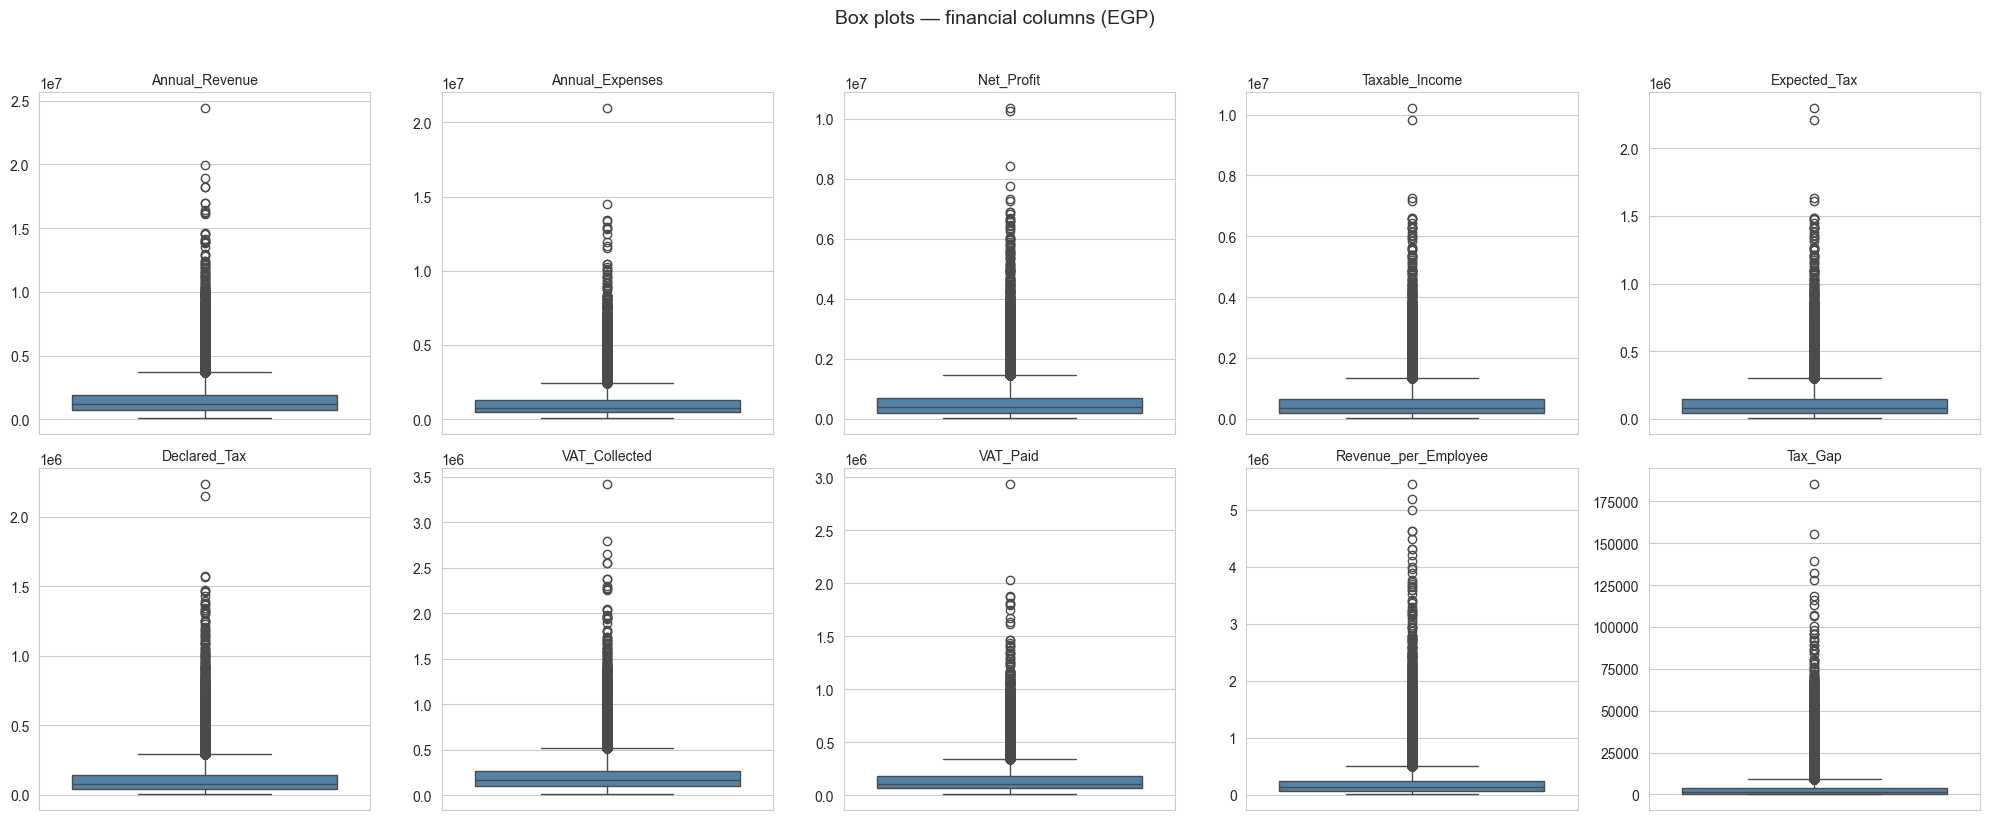

In [16]:
money_cols = ['Annual_Revenue', 'Annual_Expenses', 'Net_Profit', 'Taxable_Income',
              'Expected_Tax', 'Declared_Tax', 'VAT_Collected', 'VAT_Paid',
              'Revenue_per_Employee', 'Tax_Gap']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for ax, col in zip(axes.flat, money_cols):
    sns.boxplot(y=df[col], ax=ax, color='steelblue')
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('')
plt.suptitle('Box plots — financial columns (EGP)', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


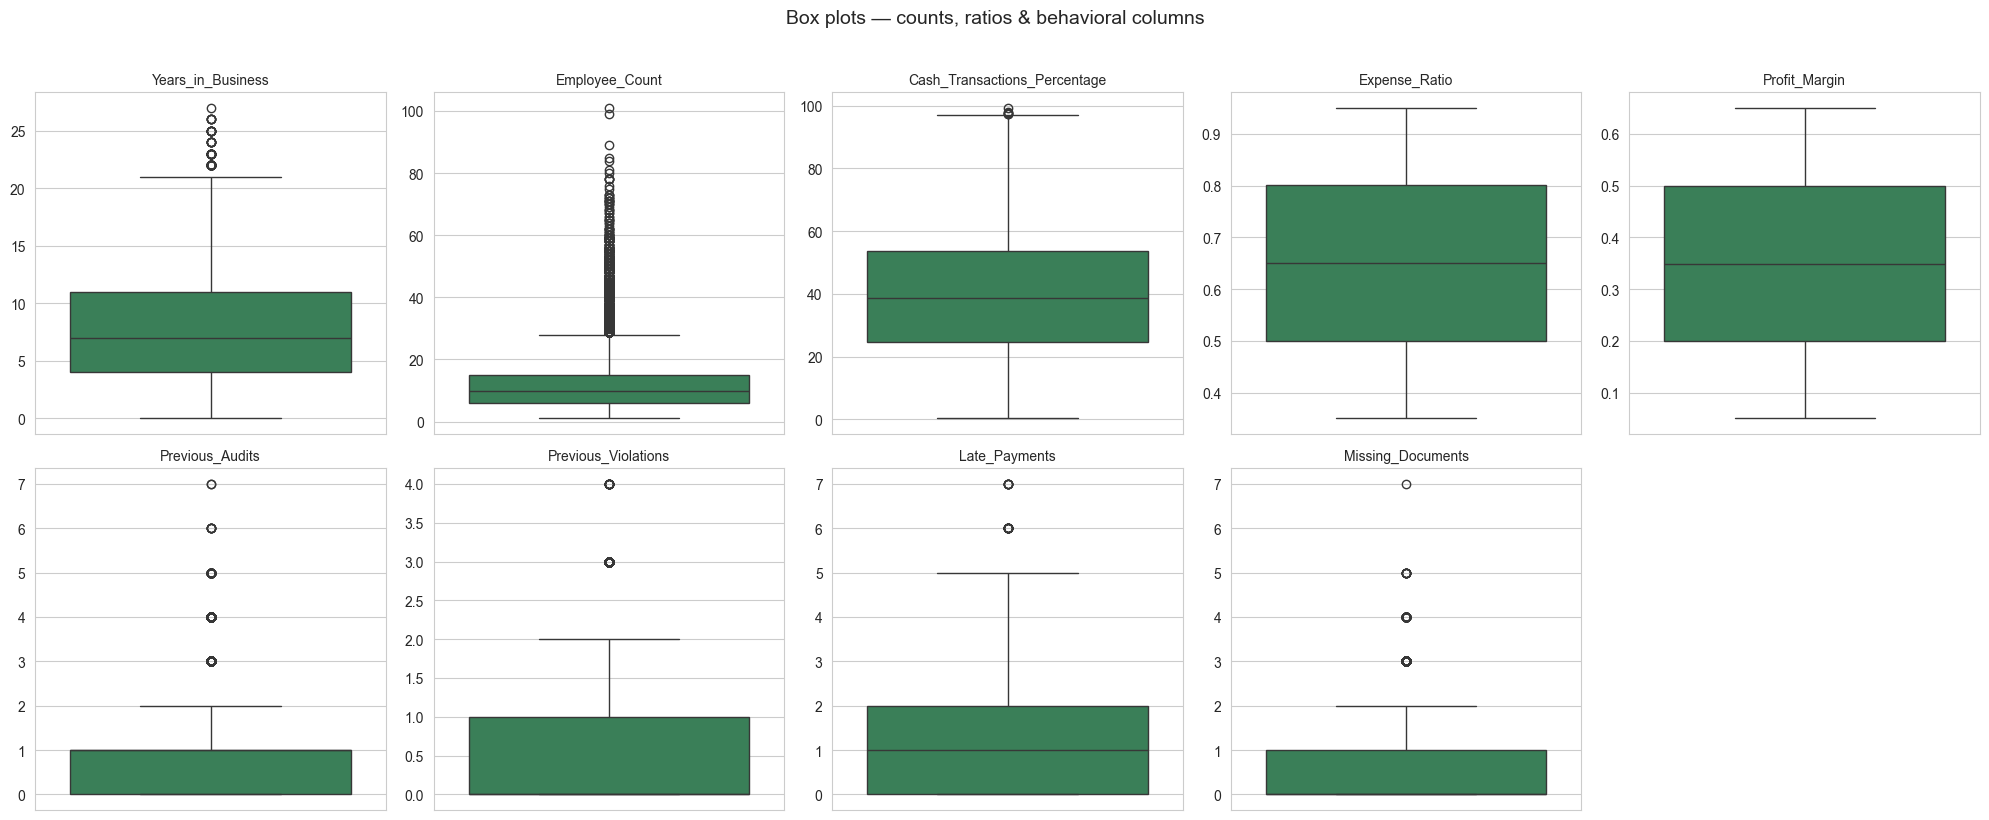

In [17]:
other_cols = ['Years_in_Business', 'Employee_Count', 'Cash_Transactions_Percentage',
              'Expense_Ratio', 'Profit_Margin', 'Previous_Audits',
              'Previous_Violations', 'Late_Payments', 'Missing_Documents']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for ax, col in zip(axes.flat, other_cols):
    sns.boxplot(y=df[col], ax=ax, color='seagreen')
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('')
axes.flat[-1].axis('off')
plt.suptitle('Box plots — counts, ratios & behavioral columns', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


In [18]:
# Quantify outliers with the IQR rule (values beyond 1.5x IQR from Q1/Q3)
outlier_summary = []
for c in money_cols + other_cols:
    q1, q3 = df[c].quantile(0.25), df[c].quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[c] < lo) | (df[c] > hi)).sum()
    outlier_summary.append({'column': c, 'n_outliers': n_out, 'pct_outliers': round(n_out / len(df) * 100, 2)})

outlier_df = pd.DataFrame(outlier_summary).sort_values('pct_outliers', ascending=False)
outlier_df


,column,n_outliers,pct_outliers
9,Tax_Gap,4721,9.44
8,Revenue_per_Employee,3758,7.52
5,Declared_Tax,3052,6.10
4,Expected_Tax,3005,6.01
3,Taxable_Income,3005,6.01
2,Net_Profit,2999,6.00
1,Annual_Expenses,2928,5.86
7,VAT_Paid,2928,5.86
0,Annual_Revenue,2696,5.39
6,VAT_Collected,2696,5.39


### Are these outliers bad data, or signal?

`Tax_Gap` has the most flagged outliers (~9%). Since `Tax_Gap` was the
strongest single predictor of fraud we found during the domain review,
let's check whether its outliers are just noise, or whether they **are**
the fraud cases.


Fraud rate among Tax_Gap outliers:     0.458
Fraud rate among Tax_Gap non-outliers:  0.071


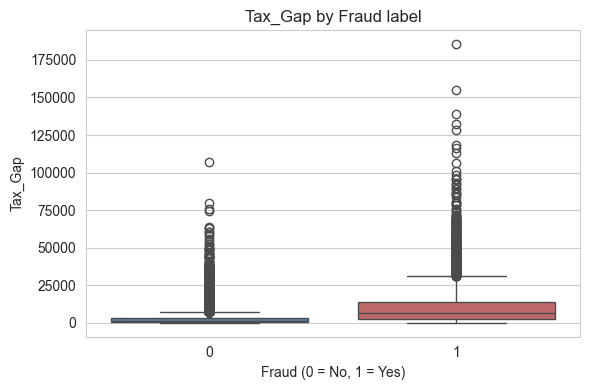

In [19]:
q1, q3 = df['Tax_Gap'].quantile(0.25), df['Tax_Gap'].quantile(0.75)
iqr = q3 - q1
lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
is_outlier = (df['Tax_Gap'] < lo) | (df['Tax_Gap'] > hi)

print(f"Fraud rate among Tax_Gap outliers:     {df.loc[is_outlier, 'Fraud'].mean():.3f}")
print(f"Fraud rate among Tax_Gap non-outliers:  {df.loc[~is_outlier, 'Fraud'].mean():.3f}")

plt.figure(figsize=(6, 4))
sns.boxplot(x='Fraud', y='Tax_Gap', hue='Fraud', data=df, palette=['steelblue', 'indianred'], legend=False)
plt.title('Tax_Gap by Fraud label')
plt.xlabel('Fraud (0 = No, 1 = Yes)')
plt.tight_layout()
plt.show()


**Decision: keep the outliers, don't remove them.**

- `Tax_Gap` outliers have a **~46% fraud rate** vs **~7%** for normal values —
  these extreme values are exactly the fraud signal we want the model to
  learn, not data errors. Removing them would delete the most useful
  evidence in the dataset.
- The other flagged columns (revenue, expenses, profit, etc.) show no such
  relationship with fraud — their "outliers" are just naturally large
  businesses (right-skewed financial data is normal), and every value we
  checked is non-negative and internally consistent (Section 5c), so there's
  no sign of data-entry errors.
- We'll leave outlier handling (e.g. scaling, transformations) to the
  modeling stage, where tree-based models (common for fraud detection) are
  naturally robust to this kind of skew.


## 7. Final Summary & Export

In [20]:
print("Final cleaned dataset:")
print(f"  Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"  Missing values remaining: {df.isnull().sum().sum()}")
print(f"  Duplicate rows remaining: {df.duplicated().sum()}")
print(f"  Fraud rate: {df['Fraud'].mean():.3f}")
df.head()


Final cleaned dataset:
  Shape: 50000 rows x 25 columns
  Missing values remaining: 0
  Duplicate rows remaining: 0
  Fraud rate: 0.107


,Taxpayer_ID,Business_Type,Region,Years_in_Business,Employee_Count,Annual_Revenue,Annual_Expenses,Net_Profit,Taxable_Income,Expected_Tax,Declared_Tax,VAT_Collected,VAT_Paid,Previous_Audits,Previous_Violations,Late_Payments,Industry_Risk,Cash_Transactions_Percentage,Missing_Documents,Invoice_Mismatch,Expense_Ratio,Profit_Margin,Revenue_per_Employee,Tax_Gap,Fraud
0,100000,Restaurant,Cairo,10,9,1892448.36,839511.26,1052937.10,919634.40,206917.74,200930.13,264942.77,117531.58,2,0,0,Medium,58.87,0,0,0.444,0.556,210272.04,5987.61,0
1,100001,Pharmacy,Giza,0,17,2129742.33,923661.40,1206080.92,1078021.30,242554.79,234562.43,298163.93,129312.60,1,0,1,Low,5.98,0,0,0.434,0.566,125278.96,7992.36,0
2,100002,Restaurant,Sharqia,4,8,789223.93,334017.67,455206.26,420736.46,94665.70,81056.42,110491.35,46762.47,1,0,0,Medium,69.98,4,1,0.423,0.577,98652.99,13609.28,1
3,100003,Manufacturing,Cairo,7,8,427211.55,361951.79,65259.77,58963.05,13266.69,12816.14,59809.62,50673.25,2,0,0,Medium,42.56,1,0,0.847,0.153,53401.44,450.54,0
4,100004,Import/Export,Sharqia,3,8,1516452.68,831833.16,684619.52,588453.59,132402.06,130966.03,212303.38,116456.64,0,1,2,High,39.09,1,0,0.549,0.451,189556.58,1436.03,0


In [ ]:
# Save a cleaned copy for the EDA notebook to build on (keeps the raw file untouched)
df.to_excel(DATA_DIR / 'tax_fraud_dataset_cleaned.xlsx', index=False)
df.to_csv(DATA_DIR / 'tax_fraud_dataset_cleaned.csv', index=False)

print("Saved: tax_fraud_dataset_cleaned.xlsx")
print("Saved: tax_fraud_dataset_cleaned.csv")


---
**Next step:** create `EDA.ipynb` to explore patterns and relationships in
`tax_fraud_dataset_cleaned.csv` (e.g. fraud rate by business type/region,
correlations, distributions) before moving on to modeling.
